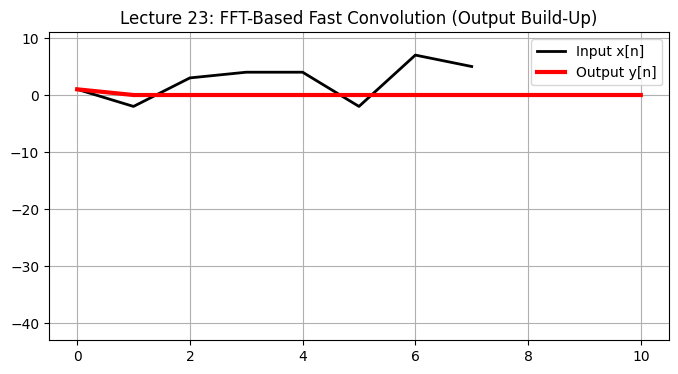

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation
from IPython.display import HTML

# -----------------------------
# Lecture 23: FFT-Based Fast Convolution
# (time-domain visualization)
# -----------------------------

# Input signal
x = np.array([1, -2, 3, 4, 4, -2, 7, 5])
N = len(x)

# FIR filter
h = np.array([1, -3, -3, 1])
M = len(h)

# Linear convolution (ground truth)
y = np.convolve(x, h)

n_x = np.arange(N)
n_y = np.arange(len(y))

# Plot setup
fig, ax = plt.subplots(figsize=(8, 4))
ax.set_xlim(-0.5, len(y) - 0.5)
ax.set_ylim(min(y) - 5, max(y) + 5)
ax.grid(True)
ax.set_title("Lecture 23: FFT-Based Fast Convolution (Output Build-Up)")

# Static input signal
ax.plot(n_x, x, 'k', lw=2, label="Input x[n]")

# Animated output signal
y_line, = ax.plot([], [], 'r', lw=3, label="Output y[n]")

ax.legend(loc="upper right")

# -----------------------------
# Animation update (Lecture-9 style)
# -----------------------------
def update(frame):
    y_display = np.zeros_like(y)
    y_display[:frame + 1] = y[:frame + 1]

    y_line.set_data(n_y, y_display)
    return (y_line,)

anim = FuncAnimation(
    fig,
    update,
    frames=len(y),
    interval=700
)

HTML(anim.to_jshtml())